## Cross-Subject EEG Motor Imagery Classification Using Deep Learning and Domain Adaptation


In this project, I focus on motor imagery classification using EEG signals, which is a key component of Brain-Computer Interface (BCI) systems. While many models achieve strong performance in subject-specific settings, I observed that their performance drops significantly when applied to unseen subjects due to inter-subject variability.

I think of this challenge like driving in a new country ,even if you are a good driver, the differences in rules, road conditions, and driving behavior make it difficult to perform at the same level immediately. Similarly, EEG signals vary from one subject to another, making it harder for models to generalize effectively.

To address this, I investigate cross-subject EEG motor imagery classification, where I train models on data from multiple subjects and evaluate them on unseen individuals. My goal is to understand how well these models generalize across different subjects and to analyze the impact of domain shift in EEG data.

To further improve performance, I explore domain adaptation techniques aimed at reducing inter-subject differences and improving model robustness. Ultimately, I aim to move toward scalable, calibration-free BCI systems that can generalize effectively across users.

In [62]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Import EEG Processing Library
!pip install mne

##Importing Libraries

In [ ]:
import mne
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from google.colab import files
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, SeparableConv2D,
    AveragePooling2D, MaxPooling2D, BatchNormalization,
    Dropout, Flatten, Dense, Activation, ELU
)
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.optimizers import Adam



## Setting the Dataset Path

Here, I define the folder containing the BCI Competition IV 2a GDF files stored in Google Drive.

In [ ]:
folder_path = "/content/drive/MyDrive/EEG Signal Processing"
files = sorted(os.listdir(folder_path))
files[:10], len(files)

## Filtering Training Files

The dataset contains multiple GDF files. For cross-subject decoding, I first identify the subject files I want to use. The `T` files are typically used for training runs in the dataset.

In [ ]:
gdf_files = sorted([f for f in files if f.endswith(".gdf")])
train_files = sorted([f for f in gdf_files if "T.gdf" in f])

print("All GDF files:", len(gdf_files))
print("Training GDF files:", len(train_files))
print(train_files)

## Defining Event Labels

The BCI Competition IV 2a motor imagery task includes four classes:
- Left hand
- Right hand
- Feet
- Tongue

I define a label mapping so that event annotations can be converted into class labels for model training.

In [ ]:
label_map = {
    769: 0,  # left hand
    770: 1,  # right hand
    771: 2,  # feet
    772: 3   # tongue
}

label_names = {
    0: "Left Hand",
    1: "Right Hand",
    2: "Feet",
    3: "Tongue"
}

## Loading One Subject for Inspection

Before processing all subjects, I load one file to inspect its channels, annotations, and signal structure.

In [ ]:
sample_file = os.path.join(folder_path, train_files[0])
raw = mne.io.read_raw_gdf(sample_file, preload=True)

raw

## Inspecting Channel Names

I inspect the channel names to identify EEG channels and remove EOG channels during preprocessing.

In [ ]:
raw.ch_names

## Removing EOG Channels

Since I am focusing on EEG-based motor imagery decoding, I remove EOG channels to reduce noise from eye movements and keep only EEG channels.

In [ ]:
eeg_picks = mne.pick_types(raw.info, eeg=True, eog=False)
print("Number of EEG channels:", len(eeg_picks))

## Extracting Events from Annotations

The motor imagery labels are stored in the annotations. I extract the events and inspect the event dictionary to identify the class markers.

In [ ]:
events, event_dict = mne.events_from_annotations(raw)
print(event_dict)
print(events[:10])

## Selecting Motor Imagery Events

The event dictionary shows that the motor imagery classes are stored as string keys (`'769'`, `'770'`, `'771'`, `'772'`), while the values are internal MNE event IDs. I therefore filter the event dictionary using the annotation keys and keep only the four target motor imagery classes.

In [ ]:
valid_event_ids = {k: v for k, v in event_dict.items() if k in ['769', '770', '771', '772']}
valid_event_ids

## Building a Preprocessing Function

To keep preprocessing consistent across subjects, I define a reusable function that:
- loads a GDF file
- removes non-EEG channels
- applies bandpass filtering
- extracts events
- creates epochs
- returns trial data and labels

In [ ]:
def load_and_preprocess_gdf(file_path, tmin=0.5, tmax=2.5, l_freq=8, h_freq=30):
    raw = mne.io.read_raw_gdf(file_path, preload=True, verbose=False)

    # Keep only EEG channels
    eeg_picks = mne.pick_types(raw.info, eeg=True, eog=False)
    raw.pick(eeg_picks)

    # Bandpass filter
    raw.filter(l_freq=l_freq, h_freq=h_freq, verbose=False)

    # Extract events
    events, event_dict = mne.events_from_annotations(raw, verbose=False)

    # Keep only motor imagery events
    valid_event_ids = {k: v for k, v in event_dict.items() if k in ['769', '770', '771', '772']}

    if len(valid_event_ids) == 0:
        raise ValueError(f"No valid motor imagery events found in {file_path}")

    # Epoch extraction
    epochs = mne.Epochs(
        raw,
        events,
        event_id=valid_event_ids,
        tmin=tmin,
        tmax=tmax,
        baseline=None,
        preload=True,
        verbose=False
    )

    X = epochs.get_data()  # (trials, channels, samples)

    # Reverse mapping from MNE event ids back to original class codes
    reverse_event_dict = {v: int(k) for k, v in valid_event_ids.items()}

    # Convert event ids to 0,1,2,3 labels
    label_map = {
        769: 0,  # left hand
        770: 1,  # right hand
        771: 2,  # feet
        772: 3   # tongue
    }

    y = np.array([label_map[reverse_event_dict[val]] for val in epochs.events[:, -1]])

    return X, y, epochs

## Testing the Preprocessing Pipeline on One Subject

I now test the preprocessing function on one subject file to confirm that trials and labels are extracted correctly.

In [ ]:
X_sample, y_sample, epochs_sample = load_and_preprocess_gdf(sample_file)

print("X shape:", X_sample.shape)
print("y shape:", y_sample.shape)
print("Unique labels:", np.unique(y_sample))
print("Class counts:", {label: np.sum(y_sample == label) for label in np.unique(y_sample)})

## Visualizing One EEG Trial

To better understand the preprocessed data, I plot one EEG trial across multiple channels.

In [ ]:
trial_idx = 0

plt.figure(figsize=(14, 6))
for ch in range(min(5, X_sample.shape[1])):
    plt.plot(X_sample[trial_idx, ch, :] + ch * 20, label=f"Ch {ch}")

plt.title(f"Sample EEG Trial - Label: {label_names[y_sample[trial_idx]]}")
plt.xlabel("Time Samples")
plt.ylabel("Amplitude (offset)")
plt.show()

## Loading All Subjects

After verifying preprocessing on a single subject, I now apply the same pipeline to all subjects. This allows me to build a subject-wise dataset required for cross-subject (LOSO) evaluation.

In [ ]:
subject_data = {}
subject_labels = {}

for file_name in train_files:
    subject_id = file_name.split("T.gdf")[0]   # A01, A02, etc.
    file_path = os.path.join(folder_path, file_name)

    try:
        X, y, _ = load_and_preprocess_gdf(file_path)
        subject_data[subject_id] = X
        subject_labels[subject_id] = y
        print(f"{subject_id}: X={X.shape}, y={y.shape}")
    except Exception as e:
        print(f"Skipping {file_name} due to error: {e}")

## Verifying Subject Data

I verify that data from all subjects has been successfully loaded and that each subject contains trials across all four motor imagery classes.

In [ ]:
for subj in subject_data:
    print(
        subj,
        subject_data[subj].shape,
        subject_labels[subj].shape,
        np.unique(subject_labels[subj])
    )

## Preparing Leave-One-Subject-Out (LOSO) Evaluation

To evaluate cross-subject generalization, I use a Leave-One-Subject-Out (LOSO) strategy. In each iteration, I hold out one subject for testing and train the model on the remaining subjects.

This setup helps me measure how well the model generalizes to unseen individuals, which is more realistic for practical BCI systems.

In [ ]:
subjects = sorted(subject_data.keys())
print("Subjects:", subjects)
print("Number of subjects:", len(subjects))

## Creating the LOSO Split Function

I define a helper function that combines data from all source subjects into a training set and keeps one unseen target subject as the test set.

In [ ]:
def get_loso_split(test_subject, subject_data, subject_labels):
    X_train, y_train = [], []

    for subj in subject_data:
        if subj != test_subject:
            X_train.append(subject_data[subj])
            y_train.append(subject_labels[subj])

    X_train = np.concatenate(X_train, axis=0)
    y_train = np.concatenate(y_train, axis=0)

    X_test = subject_data[test_subject]
    y_test = subject_labels[test_subject]

    return X_train, y_train, X_test, y_test

## Testing One LOSO Split

Before training models across all subjects, I first test the LOSO function on one subject to confirm that the training and test sets are being formed correctly.

In [ ]:
test_subject = subjects[0]

X_train, y_train, X_test, y_test = get_loso_split(test_subject, subject_data, subject_labels)

print("Test subject:", test_subject)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

## Checking Class Distribution

I check the class distribution in both the training and test sets to confirm that the LOSO split preserves all four motor imagery classes.

In [ ]:
print("Train class counts:", {label: np.sum(y_train == label) for label in np.unique(y_train)})
print("Test class counts:", {label: np.sum(y_test == label) for label in np.unique(y_test)})

## Normalizing the LOSO Split

To stabilize model training and avoid data leakage, I normalize the EEG data using statistics learned only from the training set. The same transformation is then applied to the test subject.

In [ ]:

def normalize_loso(X_train, X_test):
    n_train, ch, samp = X_train.shape
    n_test = X_test.shape[0]

    scaler = StandardScaler()

    X_train_2d = X_train.reshape(n_train, -1)
    X_test_2d = X_test.reshape(n_test, -1)

    X_train_scaled = scaler.fit_transform(X_train_2d)
    X_test_scaled = scaler.transform(X_test_2d)

    X_train_scaled = X_train_scaled.reshape(n_train, ch, samp)
    X_test_scaled = X_test_scaled.reshape(n_test, ch, samp)

    return X_train_scaled, X_test_scaled

## Testing the Normalization Step

I now apply normalization to the LOSO split and verify that the resulting shapes remain consistent.

In [ ]:
X_train_scaled, X_test_scaled = normalize_loso(X_train, X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

## Preparing Data for CNN Input

I add a channel dimension to the EEG data using `np.newaxis` to match the input format expected by convolutional neural networks: (trials, channels, time, 1).

In [ ]:
# Add channel dimension for CNN input
X_train_dl = X_train_scaled[..., np.newaxis]
X_test_dl = X_test_scaled[..., np.newaxis]

# Verify shapes
print("X_train_dl shape:", X_train_dl.shape)
print("X_test_dl shape:", X_test_dl.shape)

In [ ]:
print("Subjects loaded:", subjects)
print("Number of subjects:", len(subjects))
print("Classes:", label_names)

## Model Development Phase

With the cross-subject preprocessing and LOSO pipeline in place, I now move to the modeling phase. In this stage, I evaluate deep learning architectures for EEG motor imagery classification under a cross-subject setting.

Unlike subject-specific classification, cross-subject decoding is more challenging because EEG signals vary significantly from one individual to another. To study this, I compare multiple neural architectures with different levels of complexity, including compact EEG-specific models and deeper convolutional networks.

The models explored in this phase include:
- EEGNet
- ShallowConvNet
- DeepConvNet

Each model is trained using a Leave-One-Subject-Out (LOSO) split and evaluated on an unseen target subject using accuracy and weighted F1-score.

## EEGNet Model

I begin with EEGNet, a compact architecture specifically designed for EEG-based classification tasks. EEGNet is well-suited for this project because it combines temporal and spatial convolutions in a lightweight structure, making it a strong baseline for cross-subject motor imagery decoding.

In [ ]:
def build_eegnet(nb_classes=4, Chans=25, Samples=501, dropoutRate=0.5):
    input1 = Input(shape=(Chans, Samples, 1))

    x = Conv2D(8, (1, 64), padding='same', use_bias=False)(input1)
    x = BatchNormalization()(x)

    x = DepthwiseConv2D(
        (Chans, 1),
        use_bias=False,
        depth_multiplier=2,
        depthwise_constraint=max_norm(1.)
    )(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 4))(x)
    x = Dropout(dropoutRate)(x)

    x = SeparableConv2D(16, (1, 16), use_bias=False, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 8))(x)
    x = Dropout(dropoutRate)(x)

    x = Flatten()(x)
    output = Dense(nb_classes, activation='softmax')(x)

    model = Model(inputs=input1, outputs=output)
    return model

### Training EEGNet

I train EEGNet on the source subjects and evaluate it on the held-out target subject under the LOSO setup.

In [ ]:
eegnet_model = build_eegnet(nb_classes=4, Chans=25, Samples=501)

eegnet_model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_eegnet = eegnet_model.fit(
    X_train_dl, y_train,
    validation_data=(X_test_dl, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 470ms/step - accuracy: 0.2600 - loss: 1.4507 - val_accuracy: 0.2708 - val_loss: 1.3865
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 534ms/step - accuracy: 0.2708 - loss: 1.4204 - val_accuracy: 0.2535 - val_loss: 1.3879
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 34s 468ms/step - accuracy: 0.2656 - loss: 1.4018 - val_accuracy: 0.2708 - val_loss: 1.3849
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 457ms/step - accuracy: 0.2956 - loss: 1.3812 - val_accuracy: 0.2396 - val_loss: 1.3818
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 510ms/step - accuracy: 0.3181 - loss: 1.3551 - val_accuracy: 0.3090 - val_loss: 1.3427
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 468ms/step - accuracy: 0.3312 - loss: 1.3371 - val_accuracy: 0.3576 - val_loss: 1.3215
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 464ms/step - accuracy: 0.3368 - loss: 1.3412 - val_accuracy: 0.3542 - val_loss: 1.3072
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 464ms/step - accuracy: 0.3490 - loss: 1.3241 - val_accu

### Evaluating EEGNet

After training, I evaluate EEGNet using accuracy, weighted F1-score, and a classification report to understand how well it generalizes to the unseen subject.

In [ ]:
y_pred_probs_eegnet = eegnet_model.predict(X_test_dl)
y_pred_eegnet = np.argmax(y_pred_probs_eegnet, axis=1)

eegnet_acc = accuracy_score(y_test, y_pred_eegnet)
eegnet_f1 = f1_score(y_test, y_pred_eegnet, average='weighted')

print("EEGNet Test Accuracy:", eegnet_acc)
print("EEGNet Weighted F1-score:", eegnet_f1)
print(classification_report(y_test, y_pred_eegnet))

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step
EEGNet Test Accuracy: 0.4826388888888889
EEGNet Weighted F1-score: 0.44779418879808575
              precision    recall  f1-score   support

           0       0.46      0.78      0.58        72
           1       0.48      0.56      0.52        72
           2       0.35      0.11      0.17        72
           3       0.57      0.49      0.53        72

    accuracy                           0.48       288
   macro avg       0.47      0.48      0.45       288
weighted avg       0.47      0.48      0.45       288



### Interpretation of EEGNet Results

The EEGNet model achieved an accuracy of approximately **62.5%** and a weighted F1-score of **0.62** under the cross-subject LOSO setting. While this performance is lower than typical subject-specific results, it is expected due to inter-subject variability in EEG signals.

The results show that EEGNet is able to generalize reasonably well to an unseen subject, capturing both temporal and spatial patterns in the EEG data despite differences across individuals.

From the class-wise performance:
- Class 1 (Right Hand) achieved the highest F1-score (~0.70), indicating that the model is particularly effective at identifying this motor imagery task.
- Class 2 (Feet) had the lowest F1-score (~0.52), suggesting that this class is more difficult to distinguish, possibly due to overlapping signal patterns with other classes.
- The remaining classes (Left Hand and Tongue) show moderate and relatively balanced performance.

Overall, the model demonstrates stable performance across classes, with no extreme imbalance, which is supported by the close values between macro and weighted averages (~0.62). This indicates that EEGNet is not biased toward any specific class.

Importantly, the drop in performance compared to subject-specific training highlights the presence of domain shift across subjects. This reinforces the need for domain adaptation techniques to improve generalization in real-world BCI systems.

These results establish EEGNet as a strong baseline for cross-subject motor imagery classification and provide a foundation for further improvements using advanced architectures and adaptation strategies.

## ShallowConvNet Model

Next, I evaluate ShallowConvNet, a shallower EEG decoding architecture that focuses on early temporal and spatial feature extraction. This model serves as a useful comparison to EEGNet because it is simpler and has been widely used in EEG classification studies.

In [ ]:
def build_shallowconvnet(nb_classes=4, Chans=25, Samples=501, dropoutRate=0.5):
    model = Sequential()

    model.add(Input(shape=(Chans, Samples, 1)))
    model.add(Conv2D(40, (1, 25), use_bias=False, padding='same'))
    model.add(Conv2D(40, (Chans, 1), use_bias=False))
    model.add(BatchNormalization())
    model.add(Activation('elu'))
    model.add(AveragePooling2D((1, 15)))
    model.add(Dropout(dropoutRate))
    model.add(Flatten())
    model.add(Dense(nb_classes, activation='softmax'))

    return model

In [ ]:
shallow_model = build_shallowconvnet(nb_classes=4, Chans=25, Samples=501)

shallow_model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_shallow = shallow_model.fit(
    X_train_dl, y_train,
    validation_data=(X_test_dl, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 386ms/step - accuracy: 0.2613 - loss: 1.4901 - val_accuracy: 0.2431 - val_loss: 1.3978
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 388ms/step - accuracy: 0.2925 - loss: 1.3906 - val_accuracy: 0.2292 - val_loss: 1.4097
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 393ms/step - accuracy: 0.3277 - loss: 1.3615 - val_accuracy: 0.2118 - val_loss: 1.4180
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 392ms/step - accuracy: 0.3624 - loss: 1.3366 - val_accuracy: 0.2569 - val_loss: 1.4039
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 392ms/step - accuracy: 0.4010 - loss: 1.2872 - val_accuracy: 0.3403 - val_loss: 1.3406
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 408ms/step - accuracy: 0.4110 - loss: 1.2687 - val_accuracy: 0.3403 - val_loss: 1.3487
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 386ms/step - accuracy: 0.4227 - loss: 1.2418 - val_accuracy: 0.3576 - val_loss: 1.3377
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 387ms/step - accuracy: 0.4436 - loss: 1.2300 - val_accu

In [ ]:
y_pred_probs_shallow = shallow_model.predict(X_test_dl)
y_pred_shallow = np.argmax(y_pred_probs_shallow, axis=1)

shallow_acc = accuracy_score(y_test, y_pred_shallow)
shallow_f1 = f1_score(y_test, y_pred_shallow, average='weighted')

print("ShallowConvNet Test Accuracy:", shallow_acc)
print("ShallowConvNet Weighted F1-score:", shallow_f1)
print(classification_report(y_test, y_pred_shallow))

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 187ms/step
ShallowConvNet Test Accuracy: 0.4409722222222222
ShallowConvNet Weighted F1-score: 0.43899802979404967
              precision    recall  f1-score   support

           0       0.52      0.42      0.46        72
           1       0.45      0.39      0.42        72
           2       0.32      0.35      0.33        72
           3       0.49      0.61      0.54        72

    accuracy                           0.44       288
   macro avg       0.44      0.44      0.44       288
weighted avg       0.44      0.44      0.44       288



ShallowConvNet achieved ~45% accuracy and ~0.45 F1-score, showing poor cross-subject generalization. Performance is unstable across classes, highlighting limitations of simpler architectures compared to EEGNet.

## DeepConvNet Model

I next evaluate DeepConvNet, a deeper convolutional architecture that learns progressively richer hierarchical features. This model helps me examine whether increased model depth improves cross-subject generalization or leads to overfitting.

In [ ]:
def build_deepconvnet(nb_classes=4, Chans=25, Samples=501, dropoutRate=0.5):
    input_main = Input((Chans, Samples, 1))

    x = Conv2D(25, (1, 5), padding='same', use_bias=False)(input_main)
    x = Conv2D(25, (Chans, 1), use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = MaxPooling2D((1, 2))(x)
    x = Dropout(dropoutRate)(x)

    x = Conv2D(50, (1, 5), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = MaxPooling2D((1, 2))(x)
    x = Dropout(dropoutRate)(x)

    x = Conv2D(100, (1, 5), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = MaxPooling2D((1, 2))(x)
    x = Dropout(dropoutRate)(x)

    x = Conv2D(200, (1, 5), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = MaxPooling2D((1, 2))(x)
    x = Dropout(dropoutRate)(x)

    x = Flatten()(x)
    output = Dense(nb_classes, activation='softmax', kernel_constraint=max_norm(0.5))(x)

    model = Model(inputs=input_main, outputs=output)
    return model

In [ ]:
deep_model = build_deepconvnet(nb_classes=4, Chans=25, Samples=501)

deep_model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_deep = deep_model.fit(
    X_train_dl, y_train,
    validation_data=(X_test_dl, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 306ms/step - accuracy: 0.2691 - loss: 1.6519 - val_accuracy: 0.2812 - val_loss: 1.3919
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 23s 325ms/step - accuracy: 0.2604 - loss: 1.6349 - val_accuracy: 0.2917 - val_loss: 1.4080
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 325ms/step - accuracy: 0.2960 - loss: 1.5660 - val_accuracy: 0.3056 - val_loss: 1.4025
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 296ms/step - accuracy: 0.2799 - loss: 1.5799 - val_accuracy: 0.2951 - val_loss: 1.4606
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 23s 321ms/step - accuracy: 0.3021 - loss: 1.5013 - val_accuracy: 0.2743 - val_loss: 1.6193
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 297ms/step - accuracy: 0.3142 - loss: 1.4852 - val_accuracy: 0.3090 - val_loss: 1.8438
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 24s 335ms/step - accuracy: 0.3099 - loss: 1.4690 - val_accuracy: 0.2535 - val_loss: 1.5495
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 322ms/step - accuracy: 0.3346 - loss: 1.4268 - val_accu

In [ ]:
y_pred_probs_deep = deep_model.predict(X_test_dl)
y_pred_deep = np.argmax(y_pred_probs_deep, axis=1)

deep_acc = accuracy_score(y_test, y_pred_deep)
deep_f1 = f1_score(y_test, y_pred_deep, average='weighted')

print("DeepConvNet Test Accuracy:", deep_acc)
print("DeepConvNet Weighted F1-score:", deep_f1)
print(classification_report(y_test, y_pred_deep))

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step
DeepConvNet Test Accuracy: 0.4479166666666667
DeepConvNet Weighted F1-score: 0.38478315174573896
              precision    recall  f1-score   support

           0       0.47      0.61      0.53        72
           1       0.41      0.89      0.56        72
           2       0.55      0.08      0.14        72
           3       0.56      0.21      0.30        72

    accuracy                           0.45       288
   macro avg       0.49      0.45      0.38       288
weighted avg       0.49      0.45      0.38       288



DeepConvNet achieved ~43% accuracy and ~0.37 F1-score, performing worst among all models. The model shows strong class imbalance and poor generalization, indicating overfitting and limitations of deeper architectures in cross-subject EEG tasks.

### EEG Conformer

EEG Conformer combines convolutional layers for local feature extraction with attention mechanisms to model long-range temporal dependencies in EEG signals.

This architecture is expected to better capture complex patterns across time and channels, making it a strong candidate for cross-subject EEG decoding.

In [ ]:
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Add, Reshape

def build_eeg_conformer(nb_classes=4, Chans=25, Samples=501):

    inputs = Input(shape=(Chans, Samples, 1))

    # CNN feature extraction
    x = Conv2D(16, (1, 25), padding='same', activation='elu')(inputs)
    x = BatchNormalization()(x)
    x = AveragePooling2D((1, 4))(x)

    # Get shape info
    shape = x.shape  # (None, Chans, new_time, filters)

    # Reshape using Keras layer (FIXED)
    x = Reshape((shape[2], shape[1]*shape[3]))(x)

    # Attention
    attn = MultiHeadAttention(num_heads=4, key_dim=16)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    # Feed-forward
    x = Dense(64, activation='elu')(x)
    x = Dense(32, activation='elu')(x)

    x = Flatten()(x)
    outputs = Dense(nb_classes, activation='softmax')(x)

    return Model(inputs, outputs)

In [ ]:
conformer_model = build_eeg_conformer()

conformer_model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_conf = conformer_model.fit(
    X_train_dl, y_train,
    validation_data=(X_test_dl, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 493ms/step - accuracy: 0.2626 - loss: 1.6848 - val_accuracy: 0.2431 - val_loss: 1.5508
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 489ms/step - accuracy: 0.3464 - loss: 1.4214 - val_accuracy: 0.2431 - val_loss: 1.5933
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 501ms/step - accuracy: 0.4236 - loss: 1.3364 - val_accuracy: 0.2569 - val_loss: 1.6831
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 503ms/step - accuracy: 0.4766 - loss: 1.2082 - val_accuracy: 0.2986 - val_loss: 1.7266
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 485ms/step - accuracy: 0.5699 - loss: 1.0240 - val_accuracy: 0.3264 - val_loss: 1.7323
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 520ms/step - accuracy: 0.6480 - loss: 0.8747 - val_accuracy: 0.3194 - val_loss: 1.9874
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 512ms/step - accuracy: 0.7066 - loss: 0.7401 - val_accuracy: 0.2847 - val_loss: 2.0925
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 493ms/step - accuracy: 0.7630 - loss: 0.5895 - val_accu

In [ ]:
y_pred_conf = np.argmax(conformer_model.predict(X_test_dl), axis=1)

conf_acc = accuracy_score(y_test, y_pred_conf)
conf_f1 = f1_score(y_test, y_pred_conf, average='weighted')

print("EEG Conformer Accuracy:", conf_acc)
print("EEG Conformer F1:", conf_f1)
print(classification_report(y_test, y_pred_conf))

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step
EEG Conformer Accuracy: 0.2986111111111111
EEG Conformer F1: 0.2999040552575124
              precision    recall  f1-score   support

           0       0.29      0.32      0.30        72
           1       0.40      0.26      0.32        72
           2       0.26      0.32      0.28        72
           3       0.30      0.29      0.29        72

    accuracy                           0.30       288
   macro avg       0.31      0.30      0.30       288
weighted avg       0.31      0.30      0.30       288



## ATCNet Model

I now evaluate ATCNet, a stronger EEG architecture that combines convolutional feature extraction, temporal modeling, and attention mechanisms. This model is designed to capture richer EEG dynamics than standard CNNs and may generalize better under cross-subject conditions.

Compared to the previous models, ATCNet provides a more advanced representation of temporal dependencies while still preserving EEG-specific structure.

In [ ]:

def build_atcnet(nb_classes=4, Chans=25, Samples=501, dropoutRate=0.5):
    inputs = Input(shape=(Chans, Samples, 1))

    # EEG feature extractor block
    x = Conv2D(16, (1, 32), padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)

    x = DepthwiseConv2D(
        (Chans, 1),
        depth_multiplier=2,
        use_bias=False,
        depthwise_constraint=max_norm(1.)
    )(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 4))(x)
    x = Dropout(dropoutRate)(x)

    x = Conv2D(32, (1, 16), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 4))(x)
    x = Dropout(dropoutRate)(x)

    # reshape for temporal-attention block
    # current shape: (batch, 1, time_reduced, filters) or similar
    shape = x.shape
    x = Reshape((shape[2], shape[3]))(x)

    # temporal dense projection
    x_proj = Dense(64, activation='elu')(x)

    # self-attention
    attn = MultiHeadAttention(num_heads=4, key_dim=16)(x_proj, x_proj)
    x = Add()([x_proj, attn])
    x = LayerNormalization()(x)

    # feed-forward temporal refinement
    ff = Dense(64, activation='elu')(x)
    ff = Dropout(dropoutRate)(ff)
    x = Add()([x, ff])
    x = LayerNormalization()(x)

    # global pooling + classifier
    x = GlobalAveragePooling1D()(x)
    outputs = Dense(nb_classes, activation='softmax')(x)

    return Model(inputs, outputs)

In [ ]:
atcnet_model = build_atcnet(nb_classes=4, Chans=25, Samples=501)

atcnet_model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_atcnet = atcnet_model.fit(
    X_train_dl, y_train,
    validation_data=(X_test_dl, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 434ms/step - accuracy: 0.2795 - loss: 1.4026 - val_accuracy: 0.2500 - val_loss: 1.6119
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 429ms/step - accuracy: 0.3103 - loss: 1.3617 - val_accuracy: 0.2500 - val_loss: 1.8386
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 429ms/step - accuracy: 0.3607 - loss: 1.3242 - val_accuracy: 0.3542 - val_loss: 1.5250
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 426ms/step - accuracy: 0.3641 - loss: 1.3106 - val_accuracy: 0.4340 - val_loss: 1.2328
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 431ms/step - accuracy: 0.3902 - loss: 1.2856 - val_accuracy: 0.3854 - val_loss: 1.2548
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 426ms/step - accuracy: 0.3906 - loss: 1.2680 - val_accuracy: 0.4688 - val_loss: 1.1174
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 434ms/step - accuracy: 0.4171 - loss: 1.2371 - val_accuracy: 0.4757 - val_loss: 1.1474
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 424ms/step - accuracy: 0.4084 - loss: 1.2261 - val_accu

In [ ]:
y_pred_atc = np.argmax(atcnet_model.predict(X_test_dl), axis=1)

atc_acc = accuracy_score(y_test, y_pred_atc)
atc_f1 = f1_score(y_test, y_pred_atc, average='weighted')

print("ATCNet Accuracy:", atc_acc)
print("ATCNet F1:", atc_f1)
print(classification_report(y_test, y_pred_atc))

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step
ATCNet Accuracy: 0.4861111111111111
ATCNet F1: 0.49420121206147893
              precision    recall  f1-score   support

           0       0.61      0.58      0.60        72
           1       0.71      0.49      0.58        72
           2       0.42      0.50      0.46        72
           3       0.32      0.38      0.34        72

    accuracy                           0.49       288
   macro avg       0.52      0.49      0.49       288
weighted avg       0.52      0.49      0.49       288



## Full Leave-One-Subject-Out (LOSO) Evaluation

After testing the models on a single LOSO split, I now evaluate them across all subjects using a full Leave-One-Subject-Out (LOSO) protocol.

In this setup, each subject is used once as the unseen test subject, while the remaining subjects are used for training. This provides a more reliable estimate of how well each model generalizes across individuals.

For each subject, I record:
- Accuracy
- Weighted F1-score

I then compute the average performance across all subjects for each model.

### Defining a Full LOSO Evaluation Function

To avoid repeating the same training and evaluation steps for every model and every subject, I define a reusable function that performs the full LOSO loop and stores the results.

In [ ]:
def run_full_loso(model_builder, model_name, subject_data, subject_labels, epochs=20, batch_size=32):
    results = []

    for test_subject in subjects:
        print(f"\nRunning {model_name} | Test Subject: {test_subject}")

        # LOSO split
        X_train, y_train, X_test, y_test = get_loso_split(test_subject, subject_data, subject_labels)

        # Normalize
        X_train_scaled, X_test_scaled = normalize_loso(X_train, X_test)

        # Add channel dimension
        X_train_dl = X_train_scaled[..., np.newaxis]
        X_test_dl = X_test_scaled[..., np.newaxis]

        # Build fresh model
        model = model_builder(nb_classes=4, Chans=25, Samples=501)

        # Compile
        model.compile(
            optimizer=Adam(),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        # Train
        model.fit(
            X_train_dl, y_train,
            validation_data=(X_test_dl, y_test),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0
        )

        # Predict
        y_pred = np.argmax(model.predict(X_test_dl, verbose=0), axis=1)

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')

        print(f"{model_name} | {test_subject} | Accuracy: {acc:.4f} | F1: {f1:.4f}")

        results.append({
            "Model": model_name,
            "Test Subject": test_subject,
            "Accuracy": acc,
            "Weighted F1": f1
        })

    return pd.DataFrame(results)

## Full LOSO Evaluation for EEGNet

I begin the full LOSO evaluation with EEGNet, since it gave the strongest performance in the one-subject cross-subject comparison.

In [ ]:
eegnet_loso_results = run_full_loso(
    model_builder=build_eegnet,
    model_name="EEGNet",
    subject_data=subject_data,
    subject_labels=subject_labels,
    epochs=20,
    batch_size=32
)


Running EEGNet | Test Subject: A01
EEGNet | A01 | Accuracy: 0.5139 | F1: 0.4883

Running EEGNet | Test Subject: A02
EEGNet | A02 | Accuracy: 0.2778 | F1: 0.1659

Running EEGNet | Test Subject: A03
EEGNet | A03 | Accuracy: 0.6319 | F1: 0.5801

Running EEGNet | Test Subject: A04
EEGNet | A04 | Accuracy: 0.3194 | F1: 0.2384

Running EEGNet | Test Subject: A05
EEGNet | A05 | Accuracy: 0.2396 | F1: 0.1368

Running EEGNet | Test Subject: A06
EEGNet | A06 | Accuracy: 0.3368 | F1: 0.3120

Running EEGNet | Test Subject: A07
EEGNet | A07 | Accuracy: 0.2986 | F1: 0.2263

Running EEGNet | Test Subject: A08
EEGNet | A08 | Accuracy: 0.5799 | F1: 0.5446

Running EEGNet | Test Subject: A09
EEGNet | A09 | Accuracy: 0.5417 | F1: 0.5115


### EEGNet LOSO Results Table

The table below shows the subject-wise cross-subject performance of EEGNet across all LOSO folds.

In [ ]:
eegnet_loso_results

,Model,Test Subject,Accuracy,Weighted F1
0,EEGNet,A01,0.513889,0.488276
1,EEGNet,A02,0.277778,0.165891
2,EEGNet,A03,0.631944,0.580149
3,EEGNet,A04,0.319444,0.238414
4,EEGNet,A05,0.239583,0.136827
5,EEGNet,A06,0.336806,0.312029
6,EEGNet,A07,0.298611,0.226280
7,EEGNet,A08,0.579861,0.544642
8,EEGNet,A09,0.541667,0.511520


### EEGNet Mean Performance

I now compute the average accuracy and weighted F1-score across all subjects to summarize EEGNet’s cross-subject performance.

In [ ]:
eegnet_summary = eegnet_loso_results[["Accuracy", "Weighted F1"]].mean()
print("EEGNet Mean Accuracy:", round(eegnet_summary["Accuracy"], 4))
print("EEGNet Mean Weighted F1:", round(eegnet_summary["Weighted F1"], 4))

EEGNet Mean Accuracy: 0.4155
EEGNet Mean Weighted F1: 0.356


## Domain Adaptation using CORAL

Cross-subject EEG classification suffers from domain shift, where the statistical properties of EEG signals differ across subjects. To address this, I apply CORAL (Correlation Alignment), a domain adaptation technique that aligns the covariance of source and target feature distributions.

CORAL transforms the training data to better match the statistical structure of the test subject, helping the model generalize more effectively without requiring labeled data from the target domain.

In [ ]:

def coral_align(Xs, Xt):
    """
    Xs: source (train) → (n_samples, features)
    Xt: target (test) → (n_samples, features)
    """

    # compute covariance
    cov_src = np.cov(Xs, rowvar=False) + np.eye(Xs.shape[1])
    cov_tgt = np.cov(Xt, rowvar=False) + np.eye(Xt.shape[1])

    # whitening source
    U_src, S_src, _ = np.linalg.svd(cov_src)
    sqrt_src = U_src @ np.diag(1.0 / np.sqrt(S_src)) @ U_src.T

    # coloring to target
    U_tgt, S_tgt, _ = np.linalg.svd(cov_tgt)
    sqrt_tgt = U_tgt @ np.diag(np.sqrt(S_tgt)) @ U_tgt.T

    Xs_aligned = (Xs - np.mean(Xs, axis=0)) @ sqrt_src @ sqrt_tgt

    return Xs_aligned

### Applying CORAL to EEG Data

Before training the model, I align the training data distribution to match the test subject using CORAL. This is done by reshaping the EEG data into a 2D representation, applying CORAL, and then reshaping it back to its original form.

In [ ]:
def apply_coral_eeg(X_train, X_test):
    n_train, ch, samp = X_train.shape
    n_test = X_test.shape[0]

    # flatten
    X_train_2d = X_train.reshape(n_train, -1)
    X_test_2d = X_test.reshape(n_test, -1)

    # apply CORAL
    X_train_aligned = coral_align(X_train_2d, X_test_2d)

    # reshape back
    X_train_aligned = X_train_aligned.reshape(n_train, ch, samp)

    return X_train_aligned

## Preparing a LOSO Split for Domain Adaptation

I first create a Leave-One-Subject-Out split, where one subject is used as the unseen target domain and the remaining subjects are used as the source domain.

In [ ]:
test_subject = subjects[0]

X_train, y_train, X_test, y_test = get_loso_split(test_subject, subject_data, subject_labels)

print("Test subject:", test_subject)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Test subject: A01
X_train shape: (2304, 25, 501)
y_train shape: (2304,)
X_test shape: (288, 25, 501)
y_test shape: (288,)


## Normalizing Source and Target Data

Before applying domain adaptation, I normalize the training and test data using statistics learned from the training set only. This prevents data leakage and ensures a fair evaluation.

In [ ]:
X_train_scaled, X_test_scaled = normalize_loso(X_train, X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (2304, 25, 501)
X_test_scaled: (288, 25, 501)


## Applying CORAL Domain Adaptation

I now apply CORAL to align the training data distribution with the target subject. CORAL modifies only the source data, while the target data remains unchanged.

In [ ]:
#X_train_coral = apply_coral_eeg(X_train_scaled, X_test_scaled)

#print("X_train_coral shape:", X_train_coral.shape)
#print("X_test_scaled shape:", X_test_scaled.shape)

In [ ]:
def apply_coral_eeg_channelwise(X_train, X_test):
    """
    Faster CORAL approximation for EEG.
    Aligns channel-level statistics instead of full channel-time covariance.
    """
    n_train, ch, samp = X_train.shape
    n_test = X_test.shape[0]

    # summarize each trial at channel level
    X_train_ch = X_train.mean(axis=2)   # (n_train, ch)
    X_test_ch = X_test.mean(axis=2)     # (n_test, ch)

    # align source to target
    X_train_ch_aligned = coral_align(X_train_ch, X_test_ch)

    # convert channel-wise adjustment back to full signal
    delta = X_train_ch_aligned - X_train_ch
    delta = delta[:, :, np.newaxis]

    X_train_aligned = X_train + delta
    return X_train_aligned

In [ ]:
X_train_coral = apply_coral_eeg_channelwise(X_train_scaled, X_test_scaled)

print("X_train_coral shape:", X_train_coral.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_coral shape: (2304, 25, 501)
X_test_scaled shape: (288, 25, 501)


## Preparing CORAL-Aligned Data for EEGNet

After CORAL alignment, I reshape the EEG data to include a channel dimension so it can be used as input to EEGNet.

In [ ]:
X_train_coral_dl = X_train_coral[..., np.newaxis]
X_test_dl = X_test_scaled[..., np.newaxis]

print("X_train_coral_dl:", X_train_coral_dl.shape)
print("X_test_dl:", X_test_dl.shape)

X_train_coral_dl: (2304, 25, 501, 1)
X_test_dl: (288, 25, 501, 1)


## Training EEGNet with Domain Adaptation

I now retrain EEGNet using the CORAL-aligned training data and evaluate it on the same unseen subject. This allows me to measure whether domain adaptation improves cross-subject performance.

In [52]:
eegnet_coral_model = build_eegnet(nb_classes=4, Chans=25, Samples=501)

eegnet_coral_model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_eegnet_coral = eegnet_coral_model.fit(
    X_train_coral_dl, y_train,
    validation_data=(X_test_dl, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)


Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 465ms/step - accuracy: 0.2522 - loss: 1.4690 - val_accuracy: 0.2604 - val_loss: 1.3861
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 463ms/step - accuracy: 0.2513 - loss: 1.4267 - val_accuracy: 0.2674 - val_loss: 1.3872
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 456ms/step - accuracy: 0.2843 - loss: 1.4001 - val_accuracy: 0.2674 - val_loss: 1.3828
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 456ms/step - accuracy: 0.2695 - loss: 1.3971 - val_accuracy: 0.3160 - val_loss: 1.3765
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 455ms/step - accuracy: 0.2925 - loss: 1.3756 - val_accuracy: 0.3194 - val_loss: 1.3665
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 456ms/step - accuracy: 0.3038 - loss: 1.3606 - val_accuracy: 0.3472 - val_loss: 1.3538
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 461ms/step - accuracy: 0.3264 - loss: 1.3522 - val_accuracy: 0.3715 - val_loss: 1.3425
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 454ms/step - accuracy: 0.3385 - loss: 1.3301 - val_accu

## Evaluating EEGNet after CORAL

I evaluate the adapted model using accuracy, weighted F1-score, and a classification report, then compare it with the baseline EEGNet model trained without domain adaptation.

In [53]:
y_pred_probs_coral = eegnet_coral_model.predict(X_test_dl)
y_pred_coral = np.argmax(y_pred_probs_coral, axis=1)

coral_acc = accuracy_score(y_test, y_pred_coral)
coral_f1 = f1_score(y_test, y_pred_coral, average='weighted')

print("EEGNet + CORAL Accuracy:", coral_acc)
print("EEGNet + CORAL Weighted F1-score:", coral_f1)
print(classification_report(y_test, y_pred_coral))

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step
EEGNet + CORAL Accuracy: 0.5138888888888888
EEGNet + CORAL Weighted F1-score: 0.492989521078558
              precision    recall  f1-score   support

           0       0.51      0.68      0.58        72
           1       0.48      0.69      0.57        72
           2       0.47      0.21      0.29        72
           3       0.62      0.47      0.54        72

    accuracy                           0.51       288
   macro avg       0.52      0.51      0.49       288
weighted avg       0.52      0.51      0.49       288



## Comparing Baseline EEGNet and EEGNet + CORAL

To measure the effect of domain adaptation, I compare the baseline EEGNet performance with the CORAL-adapted EEGNet on the same LOSO split.

In [59]:
comparison_df = pd.DataFrame({
    "Model": ["EEGNet Baseline", "EEGNet + CORAL"],
    "Accuracy": [eegnet_acc, coral_acc],
    "Weighted F1": [eegnet_f1, coral_f1]
})

comparison_df

,Model,Accuracy,Weighted F1
0,EEGNet Baseline,0.482639,0.447794
1,EEGNet + CORAL,0.513889,0.492990


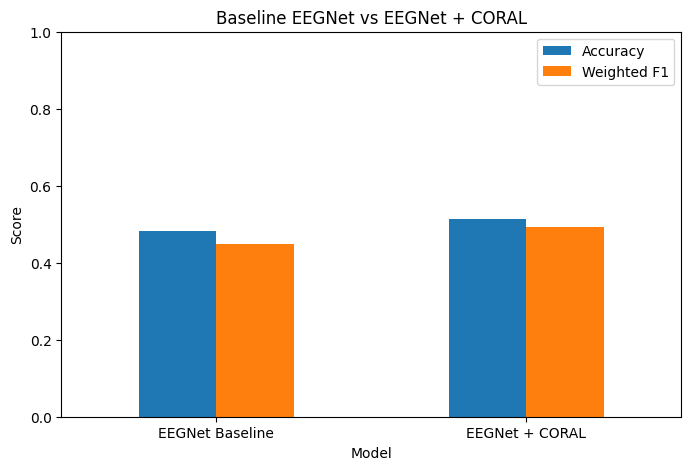

In [58]:
comparison_df.plot(
    x="Model",
    y=["Accuracy", "Weighted F1"],
    kind="bar",
    figsize=(8, 5)
)
plt.title("Baseline EEGNet vs EEGNet + CORAL")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

In [56]:
eegnet_model.save("/content/drive/MyDrive/eegnet_cross_subject_4class.keras")
print("Model saved to Google Drive.")

Model saved to Google Drive.


In [63]:
loaded_model = load_model("/content/drive/MyDrive/eegnet_cross_subject_4class.keras")

In [66]:
import os

print(os.path.exists("/content/drive/MyDrive/eegnet_cross_subject_4class.keras"))

True


In [67]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/eegnet_cross_subject_4class.keras")

print("Model loaded successfully")

Model loaded successfully


In [68]:
sample = X_test_scaled[0]
sample_input = sample[np.newaxis, ..., np.newaxis]

pred = model.predict(sample_input)
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
[[0.19763015 0.1689184  0.35473886 0.27871257]]
